# Постановка задачи

Целью данного этапа является построение модели для предсказания значения SI.

Параметр SI характеризует соотношение токсичности и противовирусной активности соединения и рассчитывается на основе IC50 и CC50.

Перед построением модели дополнительно проанализируем связь SI с этими параметрами.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, \
    HistGradientBoostingRegressor
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Загрузка данных

In [2]:
df = pd.read_excel("../data/compounds.xlsx")

df = df.drop(
    columns=[col for col in df.columns if "Unnamed" in col],
    errors="ignore"
)

df.head()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,0


# Связь SI с IC50 и CC50

На этапе EDA было показано, что SI связан с параметрами IC50 и CC50, так как рассчитывается на их основе.

Здесь кратко проверим эту связь, чтобы обосновать исключение IC50 и CC50 из признаков при обучении модели.

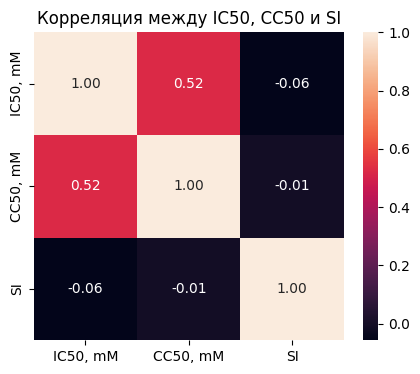

In [3]:
corr_targets = df[
    ["IC50, mM", "CC50, mM", "SI"]
].corr()

plt.figure(figsize=(5, 4))

sns.heatmap(
    corr_targets,
    annot=True,
    fmt=".2f"
)

plt.title("Корреляция между IC50, CC50 и SI")

plt.show()

Корреляционная матрица показывает, что линейная связь SI с IC50 и CC50 выражена слабо. Это связано с тем, что SI связан с IC50 и CC50 не через простую линейную зависимость, а через расчетную формулу.

Таким образом, низкая корреляция не означает отсутствия связи между переменными. Для подтверждения расчетной природы SI необходимо отдельно сравнить исходное значение SI с рассчитанным значением CC50 / IC50.

In [4]:
si_check = df["CC50, mM"] / df["IC50, mM"]

check_df = pd.DataFrame({
    "SI_original": df["SI"],
    "SI_calculated": si_check
})

check_df = check_df.replace([np.inf, -np.inf], np.nan)
check_df = check_df.dropna()

check_df.corr()

,SI_original,SI_calculated
SI_original,1.0,1.0
SI_calculated,1.0,1.0


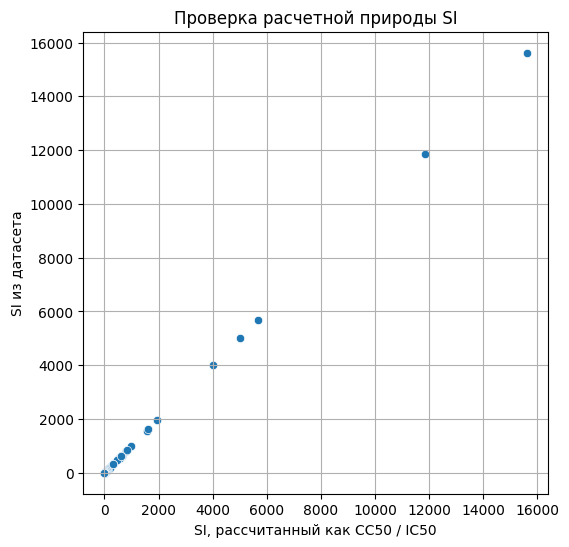

In [5]:
plt.figure(figsize=(6, 6))

sns.scatterplot(
    x=check_df["SI_calculated"],
    y=check_df["SI_original"]
)

plt.xlabel("SI, рассчитанный как CC50 / IC50")
plt.ylabel("SI из датасета")
plt.title("Проверка расчетной природы SI")

plt.grid()
plt.show()

Проверка показала, что исходное значение SI практически совпадает с величиной, рассчитанной как CC50 / IC50.

Это подтверждает, что SI является производной величиной. Поэтому при построении модели для предсказания SI признаки IC50 и CC50 исключаются из обучающего набора, чтобы избежать утечки данных.

# Подготовка данных

В качестве целевой переменной используется логарифмированное значение SI.

Логарифмирование применяется потому, что на этапе EDA было выявлено сильно асимметричное распределение SI и наличие экстремальных значений.

В качестве признаков используются только числовые характеристики соединений. Целевые переменные IC50, CC50 и SI исключаются.

In [6]:
target = "SI"

y = np.log1p(df[target])

X = df.drop(
    columns=["IC50, mM", "CC50, mM", "SI"],
    errors="ignore"
)

X = X.select_dtypes(include=["number"])

X.shape

(1001, 210)

# Разделение данных

Данные разделяются на обучающую и тестовую выборки. Тестовая выборка используется только для финальной оценки качества моделей.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Метрики качества

Для оценки моделей используются MAE, RMSE и R2.

MAE и RMSE показывают величину ошибки: чем меньше значение, тем лучше.
R2 показывает долю объясненной дисперсии: чем больше значение, тем лучше.

In [8]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

# Baseline модель

В качестве baseline используется DummyRegressor, который предсказывает среднее значение целевой переменной.

Такой подход нужен для проверки, действительно ли модели машинного обучения находят полезные закономерности в данных.

In [9]:
dummy = DummyRegressor(strategy="mean")

dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)

baseline_metrics = regression_metrics(
    y_test,
    y_pred_dummy
)

baseline_metrics

{'MAE': 1.1872786534849324,
 'RMSE': 1.556137856443579,
 'R2': -0.0006436792407946701}

# Сравнение моделей

Для решения задачи сравним несколько типов моделей:

- линейные модели
- метод ближайших соседей
- ансамбли деревьев
- бустинговые модели

Такой набор позволяет проверить, насколько хорошо разные подходы справляются с предсказанием SI.

In [10]:
models = {
    "Ridge": Ridge(),
    "Lasso": Lasso(max_iter=10000),
    "KNN": KNeighborsRegressor(),
    "RandomForest": RandomForestRegressor(random_state=42),
    "ExtraTrees": ExtraTreesRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42)
}

In [11]:
results = []

for name, model in models.items():
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold(threshold=0.0)),
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    metrics = regression_metrics(
        y_test,
        y_pred
    )

    metrics["model"] = name

    results.append(metrics)

results_df = pd.DataFrame(results)

results_df = results_df.sort_values("RMSE")

results_df

,MAE,RMSE,R2,model
3,0.928934,1.274904,0.328358,RandomForest
5,0.951325,1.301464,0.300081,GradientBoosting
6,0.918041,1.318016,0.282164,HistGradientBoosting
2,0.991857,1.338434,0.259752,KNN
4,0.939898,1.341617,0.256227,ExtraTrees
0,1.082995,1.479443,0.095559,Ridge
1,1.187279,1.556138,-0.000644,Lasso


# Визуальное сравнение моделей

Для более наглядного сравнения построим графики по основным метрикам.

Для MAE и RMSE меньшее значение означает лучшее качество.
Для R2 большее значение означает лучшее качество.

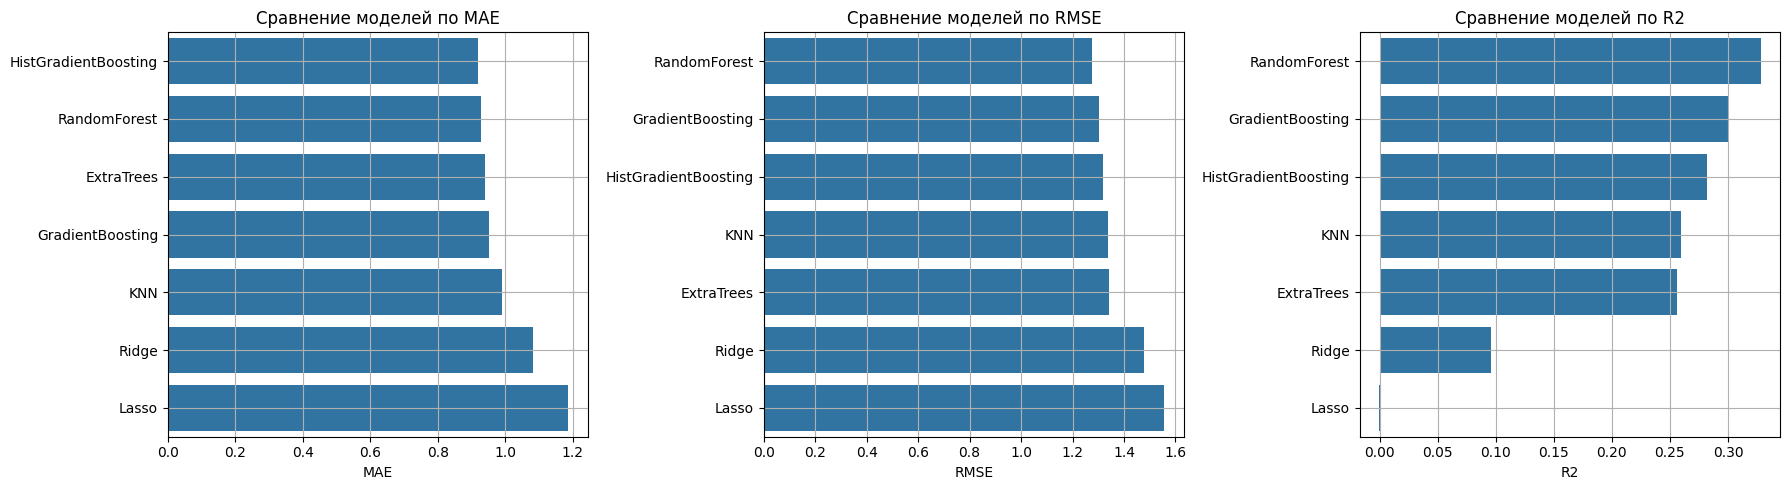

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_names = ["MAE", "RMSE", "R2"]

for i, metric in enumerate(metrics_names):
    sns.barplot(
        data=results_df.sort_values(
            metric,
            ascending=(metric != "R2")
        ),
        x=metric,
        y="model",
        ax=axes[i]
    )

    axes[i].set_title(f"Сравнение моделей по {metric}")
    axes[i].set_ylabel("")
    axes[i].grid()

plt.tight_layout()
plt.show()

# Эксперимент: логарифмирование признаков

На этапе EDA было видно, что часть признаков имеет асимметричное распределение.

Проверим, улучшит ли качество моделей логарифмирование сильно скошенных признаков.

In [13]:
X_log = X.copy()

skewness = X_log.skew()

high_skew_cols = skewness[skewness.abs() > 2].index

for col in high_skew_cols:
    if (X_log[col] >= 0).all():
        X_log[col] = np.log1p(X_log[col])

len(high_skew_cols)

96

In [14]:
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_log,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
results_log = []

for name, model in models.items():
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold()),
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    pipe.fit(X_train_log, y_train_log)

    y_pred = pipe.predict(X_test_log)

    metrics = regression_metrics(
        y_test_log,
        y_pred
    )

    metrics["model"] = name

    results_log.append(metrics)

results_df_log = pd.DataFrame(results_log)

results_df_log = results_df_log.sort_values("RMSE")

results_df_log

,MAE,RMSE,R2,model
3,0.923558,1.272681,0.330698,RandomForest
5,0.962813,1.302534,0.298929,GradientBoosting
6,0.911405,1.310514,0.290313,HistGradientBoosting
4,0.939303,1.342956,0.254742,ExtraTrees
2,1.019088,1.352275,0.244363,KNN
0,1.081154,1.466741,0.111024,Ridge
1,1.187279,1.556138,-0.000644,Lasso


По результатам сравнения моделей наилучшее качество показала модель RandomForestRegressor.

Качество моделей для SI оказалось ниже, чем для IC50 и CC50. Это связано с тем, что SI является производной величиной, зависящей от соотношения IC50 и CC50. При этом IC50 и CC50 были исключены из признаков, чтобы избежать утечки данных, поэтому задача стала сложнее.

Ансамблевые методы снова показали лучшее качество по сравнению с линейными моделями. Это подтверждает, что зависимость SI от химических характеристик соединений имеет нелинейный характер.

Эксперимент с логарифмированием признаков не дал существенного прироста качества: результат RandomForest изменился незначительно. Поэтому в качестве основного варианта используется логарифмирование только целевой переменной SI.

# Подбор гиперпараметров

После первичного сравнения моделей выполним подбор гиперпараметров для наиболее перспективных моделей.

Это позволяет не ограничиваться настройками по умолчанию и подобрать более подходящую конфигурацию модели.

In [16]:
param_grids = {
    "RandomForest": {
        "model": RandomForestRegressor(random_state=42),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [5, 10, None],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4]
        }
    },

    "GradientBoosting": {
        "model": GradientBoostingRegressor(random_state=42),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_depth": [2, 3, 5],
            "model__min_samples_leaf": [1, 2, 4]
        }
    },

    "HistGradientBoosting": {
        "model": HistGradientBoostingRegressor(random_state=42),
        "params": {
            "model__max_iter": [100, 200, 300],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_leaf_nodes": [15, 31, 63],
            "model__l2_regularization": [0.0, 0.1, 1.0]
        }
    }
}

In [17]:
top_models = results_df["model"].head(3).tolist()

grid_results = []

best_model = None
best_score = -np.inf
best_model_name = None

for name in top_models:

    if name not in param_grids:
        continue

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold()),
        ("scaler", StandardScaler()),
        ("model", param_grids[name]["model"])
    ])

    grid = GridSearchCV(
        pipe,
        param_grids[name]["params"],
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    score = grid.best_score_

    grid_results.append({
        "model": name,
        "best_score": score,
        "best_params": grid.best_params_
    })

    if score > best_score:
        best_score = score
        best_model = grid.best_estimator_
        best_model_name = name

grid_results_df = pd.DataFrame(grid_results)


grid_results_df["CV_RMSE"] = -grid_results_df["best_score"]

grid_results_df = grid_results_df.sort_values("CV_RMSE")

grid_results_df[["model", "CV_RMSE", "best_params"]]

,model,CV_RMSE,best_params
0,RandomForest,1.181872,"{'model__max_depth': 10, 'model__min_samples_l..."
2,HistGradientBoosting,1.193249,"{'model__l2_regularization': 1.0, 'model__lear..."
1,GradientBoosting,1.195868,"{'model__learning_rate': 0.03, 'model__max_dep..."


In [18]:
best_model_name

'RandomForest'

In [19]:
y_pred = best_model.predict(X_test)

best_metrics = regression_metrics(
    y_test,
    y_pred
)

best_metrics

{'MAE': 0.9310698657181781,
 'RMSE': 1.2638733083825495,
 'R2': 0.3399293768312175}

По результатам подбора гиперпараметров наилучшее качество показала модель RandomForestRegressor.

Разница между RandomForest, GradientBoosting и HistGradientBoosting оказалась небольшой, что говорит о близком качестве ансамблевых методов для данной задачи. Тем не менее RandomForest был выбран как финальная модель, так как показал лучший результат на кросс-валидации.

# Анализ качества лучшей модели

Для более детального анализа рассмотрим предсказания и ошибки лучшей модели.

Так можно понять, на каких значениях SI модель работает стабильно, а где возникают основные ошибки.

## True vs Predicted

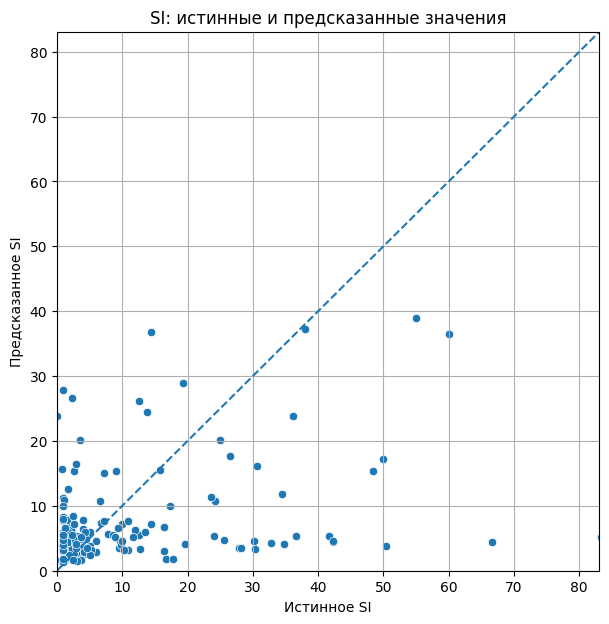

In [20]:
y_test_real = np.expm1(y_test)

y_pred_real = np.expm1(y_pred)

limit = np.percentile(np.concatenate([y_test_real, y_pred_real]), 95)

plt.figure(figsize=(7, 7))

sns.scatterplot(x=y_test_real, y=y_pred_real)

plt.plot([0, limit], [0, limit], linestyle="--")

plt.xlim(0, limit)
plt.ylim(0, limit)

plt.xlabel("Истинное SI")
plt.ylabel("Предсказанное SI")
plt.title("SI: истинные и предсказанные значения")

plt.grid()

plt.show()

График показывает, что модель лучше работает на основной массе объектов с небольшими значениями SI.

При этом для больших значений SI качество предсказаний заметно ухудшается: модель часто занижает такие значения.

Это связано с сильной асимметрией распределения SI и редкостью соединений с высоким индексом селективности.

Кроме того, SI является производной величиной от IC50 и CC50. Поскольку эти параметры были исключены из признаков для предотвращения утечки данных, задача предсказания SI становится более сложной.

## Ошибки модели

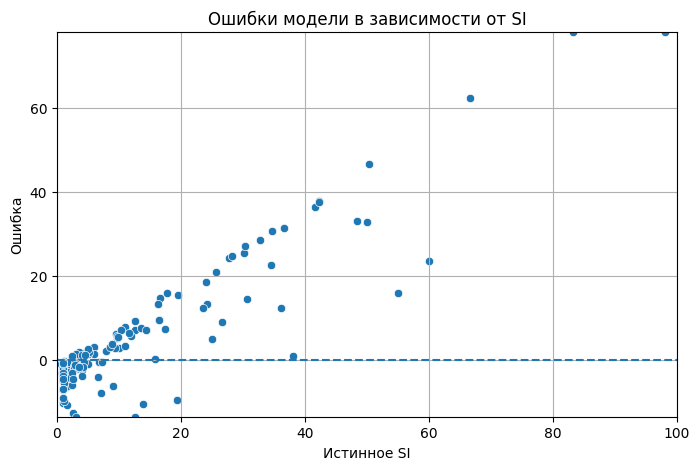

In [21]:
residuals = y_test_real - y_pred_real

x_limit = np.percentile(y_test_real, 95)
y_low = np.percentile(residuals, 5)
y_high = np.percentile(residuals, 95)

plt.figure(figsize=(8, 5))

sns.scatterplot(x=y_test_real, y=residuals)

plt.axhline(0, linestyle="--")

plt.xlim(0, x_limit)
plt.ylim(y_low, y_high)

plt.xlabel("Истинное SI")
plt.ylabel("Ошибка")
plt.title("Ошибки модели в зависимости от SI")

plt.grid()
plt.show()

Для более детального анализа основной массы объектов график был ограничен по перцентилям.

После ограничения масштаба видно, что большинство ошибок сосредоточено около нуля, однако при росте SI разброс ошибок увеличивается.

Это подтверждает, что модель лучше работает на соединениях с небольшими и средними значениями SI и хуже справляется с редкими высокими значениями.

## График в логарифмической шкале


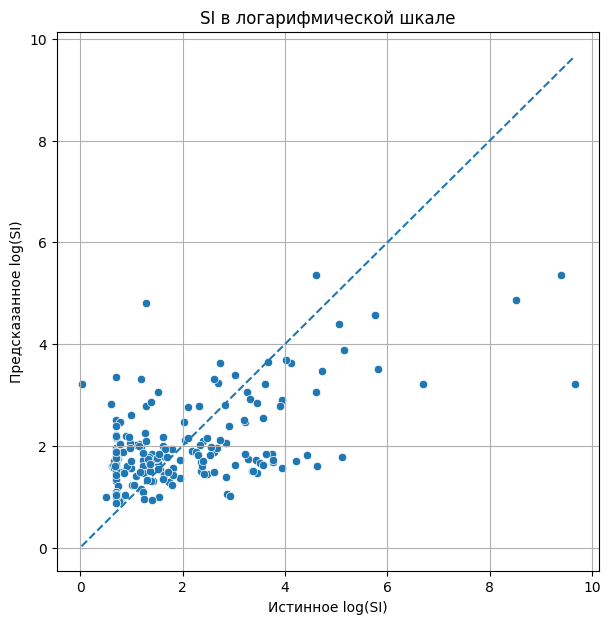

In [22]:
plt.figure(figsize=(7, 7))

sns.scatterplot(x=y_test, y=y_pred)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Истинное log(SI)")
plt.ylabel("Предсказанное log(SI)")
plt.title("SI в логарифмической шкале")

plt.grid()

plt.show()

В логарифмической шкале структура предсказаний становится более читаемой: видно, что модель улавливает общий тренд между истинными и предсказанными значениями SI.

Однако разброс точек относительно диагонали остаётся заметным, особенно для больших значений SI. Для таких объектов модель часто занижает предсказания.

Также видно, что диапазон предсказанных значений уже, чем диапазон истинных значений. Это означает, что модель стремится предсказывать более средние значения и хуже справляется с редкими экстремальными наблюдениями.

Такое поведение согласуется с тем, что SI имеет сильно асимметричное распределение и является производной величиной от IC50 и CC50, которые были исключены из признаков для предотвращения утечки данных.

# Анализ важности признаков

Для лучшей модели рассмотрим признаки, которые оказались наиболее важными при предсказании SI.

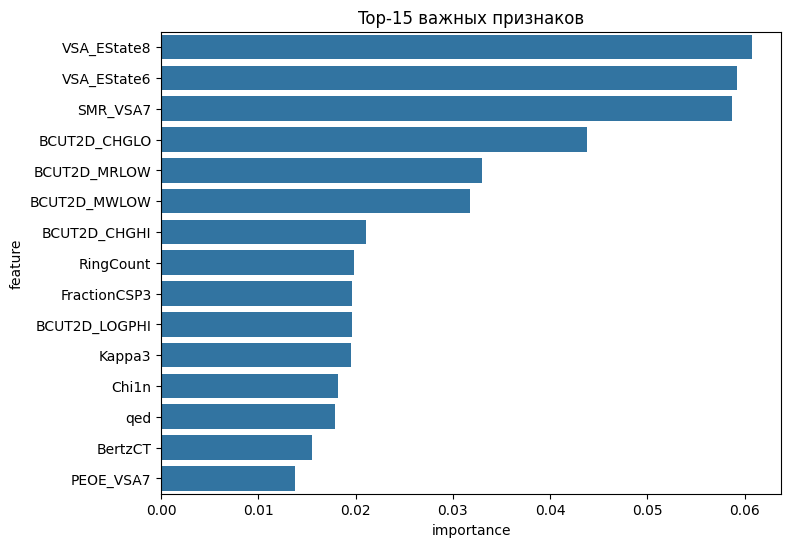

In [23]:
model = best_model.named_steps["model"]

if hasattr(model, "feature_importances_"):

    feature_names = X.columns
    if "variance" in best_model.named_steps:
        mask = best_model.named_steps["variance"].get_support()
        feature_names = feature_names[mask]

    importances = pd.DataFrame({
        "feature": feature_names,
        "importance": model.feature_importances_
    })

    importances = importances.sort_values(
        "importance",
        ascending=False
    ).head(15)

    plt.figure(figsize=(8, 6))

    sns.barplot(
        data=importances,
        x="importance",
        y="feature"
    )

    plt.title("Top-15 важных признаков")

    plt.show()

График важности признаков показывает, что модель использует сразу несколько характеристик соединений для предсказания SI.

Наиболее важными оказались признаки VSA_EState8, VSA_EState6, SMR_VSA7 и группа признаков BCUT2D. Также в топ важных признаков вошли структурные дескрипторы, такие как RingCount, FractionCSP3 и Kappa3.

Набор важных признаков частично пересекается с задачей предсказания IC50, что логично, так как SI связан с противовирусной активностью соединения. При этом модель не опирается на один единственный признак, а использует комбинацию нескольких характеристик.

Важно отметить, что высокая importance не означает причинно-следственную связь, а показывает только значимость признака внутри выбранной модели.

# Выводы

В рамках задачи была построена модель для предсказания значения SI.

Так как SI рассчитывается на основе IC50 и CC50, эти параметры были исключены из признаков, чтобы избежать утечки данных.

Перед обучением моделей была выполнена подготовка данных: пропущенные значения заменялись медианой, признаки с нулевой дисперсией удалялись, признаки масштабировались, а целевая переменная была логарифмирована.

Сравнение моделей показало, что наиболее эффективными являются модели, способные учитывать сложные нелинейные зависимости.

Линейные модели показали более слабое качество, что согласуется с выводами EDA о сложной структуре данных и слабых линейных связях.

Анализ визуализаций показал, что модель улавливает общую зависимость между химическими характеристиками соединений и SI, однако на редких экстремальных значениях ошибки возрастают.

Это связано с сильной асимметрией распределения SI и большим количеством малых значений при наличии отдельных очень больших значений.

Анализ важности признаков показал, что модель использует комбинацию нескольких характеристик соединений. Это подтверждает, что SI не определяется одним простым признаком, а зависит от совокупности химических характеристик.

Таким образом, для предсказания SI наиболее качественным решением в рамках проведённых экспериментов стала модель RandomForestRegressor. Она показала лучший результат среди рассмотренных моделей и оказалась устойчивее линейных методов. При интерпретации результатов важно учитывать расчетную природу SI и то, что IC50 и CC50 были исключены из признаков для предотвращения утечки данных.